# Notebook 5: Churn Labeling and Train-Test Split

In this notebook I define what "churn" means for this business and attach a binary label to every customer record. I then produce the stratified train/test split files that all downstream classification notebooks consume.

**Steps:**
1. Imports and load customer features
2. Apply churn definition (60-day recency threshold)
3. Visualise churn distribution
4. Analyse churn rates by RFM segment, customer segment and age group
5. Stratified train-test split (80/20, stratified on churn label)
6. Prepare feature matrix and target vector
7. Save splits and metadata to disk

## Step 1: Imports and Data Load

I import only the standard libraries needed here — pandas, numpy, matplotlib and json. There are no heavy ML imports because this notebook purely labels data and splits it; the actual model training happens in notebook 06a.

I load `customer_features.csv`, which was built in notebook 3 from the cleaned transactional data. Each row represents one customer with all their aggregated behavioural, temporal and demographic features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import json

In [2]:
# Load the customer-level features produced by notebook 3
customer_features = pd.read_csv('../data/customer_features.csv')

print(f"Loaded features for {len(customer_features):,} customers")
print(f"Total feature columns: {customer_features.shape[1] - 1}")

Loaded features for 86,740 customers
Total feature columns: 54


## Step 2: Apply Churn Definition

I define churn using a **60-day recency threshold**: any customer whose last purchase was more than 60 days ago is labelled as churned (1), and everyone else is labelled active (0).

I chose 60 days because the dataset spans roughly a year and the median inter-purchase gap in the data sits well below that value. A shorter threshold (e.g. 30 days) would label too many seasonal shoppers as churned, inflating the churn rate artificially. A longer threshold (e.g. 90 days) would miss early warning signals. 60 days strikes a practical balance for the retail context here.

In [3]:
# 60 days is the business-agreed recency cut-off for churn
CHURN_THRESHOLD_DAYS = 60

# Customers with Recency_Days > threshold are labelled churned (1), else active (0)
customer_features['Churn'] = (customer_features['Recency_Days'] > CHURN_THRESHOLD_DAYS).astype(int)

In [4]:
# Summarise how the churn label distributed across the customer base
total_customers = len(customer_features)
churned_customers = customer_features['Churn'].sum()
active_customers = total_customers - churned_customers
churn_rate = (churned_customers / total_customers) * 100

print(f"Churn threshold: {CHURN_THRESHOLD_DAYS} days since last purchase")
print(f"\nChurn distribution:")
print(f"  Total customers : {total_customers:,}")
print(f"  Active  (0)     : {active_customers:,}  ({100 - churn_rate:.2f}%)")
print(f"  Churned (1)     : {churned_customers:,}  ({churn_rate:.2f}%)")

Churn threshold: 60 days since last purchase

Churn distribution:
  Total customers : 86,740
  Active  (0)     : 38,390  (44.26%)
  Churned (1)     : 48,350  (55.74%)


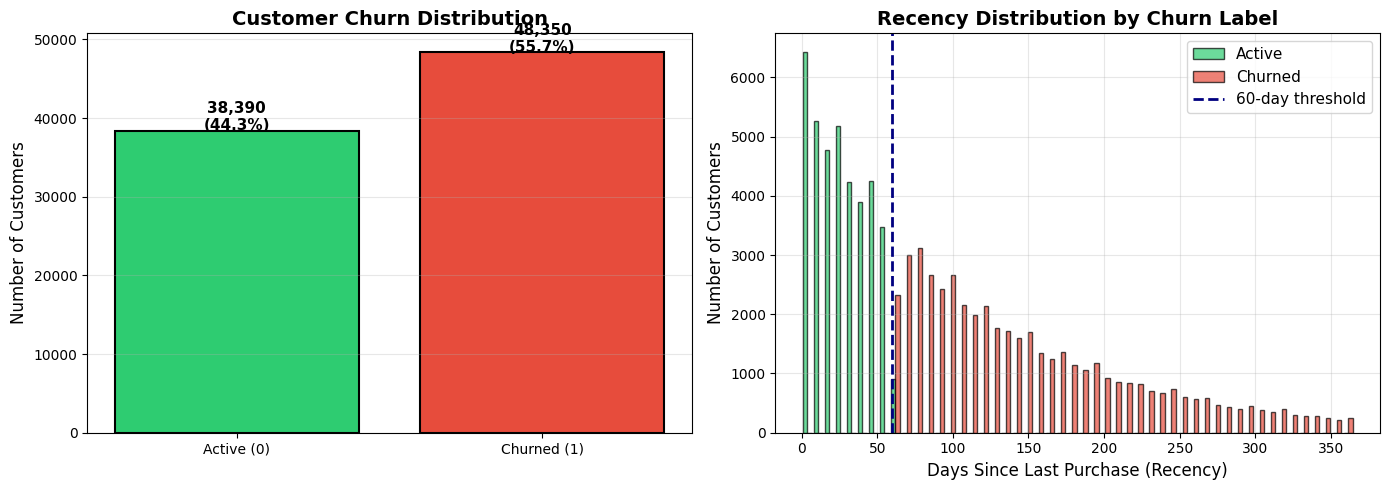

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart of active vs churned customer counts
churn_counts = customer_features['Churn'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Active (0)', 'Churned (1)'], churn_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Number of Customers', fontsize=12)
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v / total_customers * 100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=11)

# Plot 2: Overlapping recency histograms — shows natural separation at the threshold
axes[1].hist(
    [customer_features.loc[customer_features['Churn'] == 0, 'Recency_Days'],
     customer_features.loc[customer_features['Churn'] == 1, 'Recency_Days']],
    bins=50, label=['Active', 'Churned'], color=colors, alpha=0.7, edgecolor='black'
)
axes[1].axvline(x=CHURN_THRESHOLD_DAYS, color='navy', linestyle='--', linewidth=2,
                label=f'{CHURN_THRESHOLD_DAYS}-day threshold')
axes[1].set_xlabel('Days Since Last Purchase (Recency)', fontsize=12)
axes[1].set_ylabel('Number of Customers', fontsize=12)
axes[1].set_title('Recency Distribution by Churn Label', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

In [6]:
plt.savefig('../reports/churn_distribution.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"Churn distribution chart saved to: ../reports/churn_distribution.png")

Churn distribution chart saved to: ../reports/churn_distribution.png


## Step 3: Churn Rates by Segment

I break the churn rate down by RFM score, customer segment and age group. This is not modelling — it is a sanity check to confirm the label is behaving as expected. I expect lower RFM scores and lower-value segments to show higher churn rates, which would validate that the 60-day threshold is capturing real disengagement rather than just noise.

In [7]:
# Churn rate by RFM composite score — lower RFM should mean higher churn
if 'RFM_Score' in customer_features.columns:
    rfm_churn = customer_features.groupby('RFM_Score')['Churn'].agg(['sum', 'count', 'mean'])
    rfm_churn.columns = ['Churned_Count', 'Total_Count', 'Churn_Rate']
    rfm_churn['Churn_Rate'] = rfm_churn['Churn_Rate'] * 100
    print("Churn rate by RFM score:")
    print(rfm_churn.round(2))

Churn rate by RFM score:
           Churned_Count  Total_Count  Churn_Rate
RFM_Score                                        
3.0                 5033         5033      100.00
4.0                 5364         5364      100.00
5.0                 5589         5822       96.00
6.0                 5563         6813       81.65
7.0                 5201         7596       68.47
8.0                 4908         7930       61.89
9.0                 4459         8034       55.50
10.0                4012         8036       49.93
11.0                3553         8189       43.39
12.0                2985         7965       37.48
13.0                1683         6808       24.72
14.0                   0         5481        0.00
15.0                   0         3669        0.00


In [8]:
# Churn rate by segment label (Premium / Standard / Basic)
if 'Customer_Segment' in customer_features.columns:
    segment_churn = customer_features.groupby('Customer_Segment')['Churn'].agg(['sum', 'count', 'mean'])
    segment_churn.columns = ['Churned_Count', 'Total_Count', 'Churn_Rate']
    segment_churn['Churn_Rate'] = segment_churn['Churn_Rate'] * 100
    print("Churn rate by customer segment:")
    print(segment_churn.round(2))

Churn rate by customer segment:
                  Churned_Count  Total_Count  Churn_Rate
Customer_Segment                                        
New                       14506        26020       55.75
Premium                   10129        18287       55.39
Regular                   23715        42433       55.89


In [9]:
# Churn rate by age group — check whether a demographic skew exists
if 'Age_Group' in customer_features.columns:
    age_churn = customer_features.groupby('Age_Group')['Churn'].agg(['sum', 'count', 'mean'])
    age_churn.columns = ['Churned_Count', 'Total_Count', 'Churn_Rate']
    age_churn['Churn_Rate'] = age_churn['Churn_Rate'] * 100
    print("Churn rate by age group:")
    print(age_churn.round(2))

Churn rate by age group:
           Churned_Count  Total_Count  Churn_Rate
Age_Group                                        
18-24              17632        31524       55.93
25-34              10484        18925       55.40
35-44               4163         7554       55.11
45-54               8960        16124       55.57
55-64               4661         8217       56.72
65+                 2450         4396       55.73


## Step 4: Stratified Train-Test Split

I use a **stratified random 80/20 split** rather than a time-based split. A time-based split looks more realistic in theory, but for this dataset it produces severe class imbalance in the test window because churn events cluster differently in early versus late periods. Stratification guarantees that both the train and test sets have the same churn rate as the original data, which gives more reliable F1 and ROC-AUC estimates during model evaluation.

In [10]:
from sklearn.model_selection import train_test_split

# 20% held out for final evaluation; 42 is my standard random seed for reproducibility
TEST_SIZE = 0.20
RANDOM_STATE = 42

print(f"Split strategy  : stratified random")
print(f"Train / test    : {int((1 - TEST_SIZE) * 100)}% / {int(TEST_SIZE * 100)}%")
print(f"Random state    : {RANDOM_STATE}")

Split strategy  : stratified random
Train / test    : 80% / 20%
Random state    : 42


## Step 5: Prepare Feature Matrix and Target Vector

I drop non-numeric columns (dates, free-text categoricals that have not been encoded) and build the feature matrix `X`. String-typed columns would cause scikit-learn to raise an error during `fit`, so I explicitly exclude them here. The full encoding of those columns happens in notebook 06a where I have the full preprocessing pipeline in place.

In [11]:
# Columns that must not enter the feature matrix
# Date columns would leak temporal information; free-text categoricals need encoding first
exclude_cols = [
    'Customer_ID', 'Churn',
    'First_Purchase_Date', 'Last_Purchase_Date',
    'Preferred_Day', 'Favorite_Category',
    'Preferred_Payment', 'Preferred_Shipping',
]

# Start with everything not explicitly excluded
feature_cols = [col for col in customer_features.columns if col not in exclude_cols]

# Drop any remaining object-type columns — they have not been encoded yet
categorical_cols = customer_features[feature_cols].select_dtypes(include=['object']).columns.tolist()
if categorical_cols:
    print(f"Dropping un-encoded string columns: {categorical_cols}")
    feature_cols = [col for col in feature_cols if col not in categorical_cols]

print(f"Features selected for modelling : {len(feature_cols)}")
print(f"First 10 feature names          : {feature_cols[:10]}")

Dropping un-encoded string columns: ['Gender', 'Income', 'City', 'State', 'Country', 'Customer_Segment', 'Age_Group']
Features selected for modelling : 41
First 10 feature names          : ['Transaction_Count', 'Total_Spend', 'Avg_Order_Value', 'Std_Order_Value', 'Frequency', 'Recency_Days', 'Customer_Tenure_Days', 'Transactions_Per_Month', 'Customer_LTV', 'Avg_Days_Between_Purchases']


In [12]:
# Build the feature matrix and target vector, then split
X = customer_features[feature_cols]
y = customer_features['Churn']

# stratify=y ensures the churn rate is the same in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Total samples : {len(X):,}")
print(f"Train samples : {len(X_train):,}")
print(f"Test samples  : {len(X_test):,}")
print(f"\nMissing values — X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values — X_test : {X_test.isnull().sum().sum()}")

Total samples : 86,740
Train samples : 69,392
Test samples  : 17,348

Missing values — X_train: 0
Missing values — X_test : 0


In [13]:
# Confirm shapes and that stratification preserved the class ratio in both sets
print("Dataset shapes:")
print(f"  X_train : {X_train.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_test  : {y_test.shape}")

print("\nClass distribution after stratified split:")
print(f"  Train — active  : {(y_train == 0).sum():,}  ({(y_train == 0).mean() * 100:.2f}%)")
print(f"  Train — churned : {(y_train == 1).sum():,}  ({(y_train == 1).mean() * 100:.2f}%)")
print(f"  Test  — active  : {(y_test == 0).sum():,}  ({(y_test == 0).mean() * 100:.2f}%)")
print(f"  Test  — churned : {(y_test == 1).sum():,}  ({(y_test == 1).mean() * 100:.2f}%)")

Dataset shapes:
  X_train : (69392, 41)
  y_train : (69392,)
  X_test  : (17348, 41)
  y_test  : (17348,)

Class distribution after stratified split:
  Train — active  : 30,712  (44.26%)
  Train — churned : 38,680  (55.74%)
  Test  — active  : 7,678  (44.26%)
  Test  — churned : 9,670  (55.74%)


## Step 6: Save Splits and Metadata

I save four CSV files (X_train, X_test, y_train, y_test) plus a JSON metadata file. The metadata captures threshold, split strategy, random state and per-set class distributions so that any future collaborator can reproduce exactly the same split without reading through the notebook code. Notebook 06a loads these files directly.

In [14]:
# Save the four split files consumed by the churn modelling notebook
X_train.to_csv('../data/X_train_churn.csv', index=False)
y_train.to_csv('../data/y_train_churn.csv', index=False, header=['Churn'])
X_test.to_csv('../data/X_test_churn.csv', index=False)
y_test.to_csv('../data/y_test_churn.csv', index=False, header=['Churn'])

print(f"Train features saved : ../data/X_train_churn.csv  ({X_train.shape})")
print(f"Train labels saved   : ../data/y_train_churn.csv  ({y_train.shape})")
print(f"Test features saved  : ../data/X_test_churn.csv   ({X_test.shape})")
print(f"Test labels saved    : ../data/y_test_churn.csv   ({y_test.shape})")

Train features saved : ../data/X_train_churn.csv  ((69392, 41))
Train labels saved   : ../data/y_train_churn.csv  ((69392,))
Test features saved  : ../data/X_test_churn.csv   ((17348, 41))
Test labels saved    : ../data/y_test_churn.csv   ((17348,))


In [15]:
# Build a metadata dictionary so the downstream modelling notebook can verify its inputs
split_metadata = {
    'created_at': datetime.now().isoformat(),
    'churn_threshold_days': CHURN_THRESHOLD_DAYS,
    'split_strategy': 'stratified_random',
    'test_size': TEST_SIZE,
    'random_state': RANDOM_STATE,
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'n_features': len(feature_cols),
    'feature_names': feature_cols,
    'train_class_distribution': {
        'active': int((y_train == 0).sum()),
        'churned': int((y_train == 1).sum()),
        'churn_rate_pct': round(float((y_train == 1).mean() * 100), 4),
    },
    'test_class_distribution': {
        'active': int((y_test == 0).sum()),
        'churned': int((y_test == 1).sum()),
        'churn_rate_pct': round(float((y_test == 1).mean() * 100), 4),
    },
    'class_balance': 'imbalanced' if abs((y_train == 1).mean() - 0.5) > 0.2 else 'balanced',
    'stratified': True,
}

with open('../data/train_test_metadata_churn.json', 'w') as f:
    json.dump(split_metadata, f, indent=2)

print(f"Metadata saved to: ../data/train_test_metadata_churn.json")

Metadata saved to: ../data/train_test_metadata_churn.json


In [16]:
# Integrity check 1: confirm stratification kept churn rates aligned
train_churn_rate = (y_train == 1).mean() * 100
test_churn_rate  = (y_test  == 1).mean() * 100
rate_diff        = abs(train_churn_rate - test_churn_rate)

print("Class balance verification:")
print(f"  Train churn rate : {train_churn_rate:.2f}%")
print(f"  Test churn rate  : {test_churn_rate:.2f}%")
print(f"  Difference       : {rate_diff:.2f}%  ({'OK' if rate_diff < 2.0 else 'WARNING: large divergence'})")

# Integrity check 2: both classes must appear in both sets
print(f"\nClass presence:")
print(f"  Train classes : {sorted(y_train.unique())} — {'OK' if y_train.nunique() == 2 else 'ERROR'}")
print(f"  Test classes  : {sorted(y_test.unique())} — {'OK' if y_test.nunique() == 2 else 'ERROR'}")

# Integrity check 3: spot-check mean feature values between train and test
print("\nFeature mean comparison (first 5 features):")
for col in feature_cols[:5]:
    tr_mean = X_train[col].mean()
    te_mean = X_test[col].mean()
    pct_diff = abs(tr_mean - te_mean) / (abs(tr_mean) + 1e-9) * 100
    print(f"  {col:<35} train={tr_mean:8.2f}  test={te_mean:8.2f}  diff={pct_diff:5.1f}%")

Class balance verification:
  Train churn rate : 55.74%
  Test churn rate  : 55.74%
  Difference       : 0.00%  (OK)

Class presence:
  Train classes : [np.int64(0), np.int64(1)] — OK
  Test classes  : [np.int64(0), np.int64(1)] — OK

Feature mean comparison (first 5 features):
  Transaction_Count                   train=    3.47  test=    3.45  diff=  0.7%
  Total_Spend                         train= 4751.90  test= 4724.81  diff=  0.6%
  Avg_Order_Value                     train= 1368.26  test= 1369.38  diff=  0.1%
  Std_Order_Value                     train=  859.93  test=  855.50  diff=  0.5%
  Frequency                           train=    3.47  test=    3.45  diff=  0.7%


In [17]:
# Hard assertions — the notebook must not proceed silently with corrupted splits
assert X_train.isnull().sum().sum() == 0, "Missing values found in X_train"
assert X_test.isnull().sum().sum()  == 0, "Missing values found in X_test"
assert not np.isinf(X_train.values).any(), "Infinite values found in X_train"
assert not np.isinf(X_test.values).any(),  "Infinite values found in X_test"

print("All integrity assertions passed.")
print(f"\nNotebook 5 complete.")
print(f"  Churn threshold      : {CHURN_THRESHOLD_DAYS} days")
print(f"  Churn rate           : {churn_rate:.2f}%")
print(f"  Features for model   : {len(feature_cols)}")
print(f"  Train / test sizes   : {len(X_train):,} / {len(X_test):,}")

All integrity assertions passed.

Notebook 5 complete.
  Churn threshold      : 60 days
  Churn rate           : 55.74%
  Features for model   : 41
  Train / test sizes   : 69,392 / 17,348
